<a href="https://colab.research.google.com/github/JonLiki/CS412-Labs/blob/main/Lab3_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS412 Lab 3 — Logistic Regression


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Raw Data

All 30 patient records. Columns: BP, Cholesterol, Age, Pregnant, DrugReaction.

In [ ]:
# Columns: BP, Cholesterol, Age, Pregnant, DrugReaction
raw_data = np.array([
    [100, 150, 20, 0, 0],
    [120, 160, 16, 0, 0],
    [110, 150, 18, 0, 0],
    [100, 175, 25, 0, 0],
    [ 95, 250, 36, 0, 0],
    [110, 200, 56, 0, 0],
    [120, 180, 59, 0, 0],
    [150, 175, 45, 0, 0],
    [160, 185, 40, 0, 0],
    [125, 195, 20, 1, 0],
    [135, 190, 18, 1, 0],
    [165, 200, 25, 1, 0],
    [145, 175, 30, 1, 0],
    [120, 180, 28, 1, 0],
    [100, 180, 21, 1, 0],
    [100, 160, 19, 1, 1],
    [ 95, 250, 18, 1, 1],
    [120, 200, 30, 1, 1],
    [125, 240, 29, 1, 1],
    [130, 172, 30, 1, 1],
    [120, 130, 35, 1, 1],
    [120, 140, 38, 1, 1],
    [125, 160, 32, 1, 1],
    [115, 185, 40, 1, 1],
    [150, 195, 65, 0, 1],
    [130, 175, 72, 0, 1],
    [170, 200, 56, 0, 1],
    [145, 210, 58, 0, 1],
    [180, 200, 81, 0, 1],
    [140, 190, 73, 0, 1],
], dtype=float)


## 2. Features and Labels

Separate inputs from labels. Convert labels 0→−1, 1→+1 as required by the logistic loss formula.

In [ ]:
X = raw_data[:, :4]               # BP, Cholesterol, Age, Pregnant
y_raw = raw_data[:, 4]            # 0 or 1
y = np.where(y_raw == 1, 1, -1)  # convert to +1 / -1


## 3. Feature Normalisation

Scale each feature to zero-mean, unit-variance using training statistics only.

In [ ]:
def normalize(X_train, X_test):
    mean = X_train.mean(axis=0)
    std  = X_train.std(axis=0)
    std[std == 0] = 1          # guard against zero-variance columns
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


## 4. Train / Test Split (60% / 40%)

In [ ]:
def train_test_split(X, y, test_ratio=0.4, seed=42):
    np.random.seed(seed)        # fixed seed for reproducibility
    n = len(y)
    idx = np.random.permutation(n)
    split = int(n * (1 - test_ratio))
    train_idx, test_idx = idx[:split], idx[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.4)

# Normalise using training statistics only
X_train_n, X_test_n, feat_mean, feat_std = normalize(X_train, X_test)

# Add bias column (column of ones)
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train_n)
X_test_b  = add_bias(X_test_n)


## 5. Logistic Regression


**Logistic function θ:**
$$\theta(s) = \frac{e^s}{1 + e^s} = \frac{1}{1 + e^{-s}}$$

**Cross-entropy loss E_in:**
$$E_{in}(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^{N} \ln\left(1 + e^{-y_n \mathbf{w}^\top \mathbf{x}_n}\right)$$

**Gradient:**
$$\nabla E_{in} = -\frac{1}{N} \sum_{n=1}^{N} \frac{y_n \mathbf{x}_n}{1 + e^{y_n \mathbf{w}^\top \mathbf{x}_n}}$$

**Weight update:**
$$\mathbf{w}(t+1) = \mathbf{w}(t) - \eta \cdot \nabla E_{in}$$

In [ ]:
def sigmoid(z):
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


def compute_loss(X, y, w):
    """cross-entropy loss.
    E_in(w) = (1/N) * sum( ln(1 + exp(-y_n * w^T x_n)) )
    """
    margins  = y * (X @ w)                           # y_n * w^T x_n
    log_loss = np.mean(np.log(1 + np.exp(-margins)))
    return log_loss


def logistic_regression_train(X, y, lr=0.1, epochs=1000, verbose=True):
    """Train logistic regression
    """
    n, d = X.shape
    w = np.zeros(d)        # step 1: initialise w(0)
    losses = []

    for epoch in range(epochs):
        # step 3 — gradient
        margins = y * (X @ w)                         # y_n * w^T x_n
        probs   = sigmoid(-margins)                   # 1/(1+e^(y_n*w^T*x_n))
        grad    = (-1/n) * (X.T @ (y * probs))

        # step 4 — update (gradient descent)
        w -= lr * grad                                # w(t+1) = w(t) - eta * grad

        loss = compute_loss(X, y, w)
        losses.append(loss)

        if verbose and (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:4d}/{epochs}  |  Loss: {loss:.6f}")

    return w, losses


def predict(X, w):
    """Return predicted labels {-1, +1}."""
    scores = X @ w
    return np.where(scores >= 0, 1, -1)


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100


## 6. Train the Model

  CS412 Lab 3 — Logistic Regression

Dataset size : 30 samples
Training set : 18 samples (60%)
Test set     : 12 samples (40%)
Features     : BP, Cholesterol, Age, Pregnant

Training logistic regression ...
---------------------------------------------
  Epoch  100/1000  |  Loss: 0.499524
  Epoch  200/1000  |  Loss: 0.450759
  Epoch  300/1000  |  Loss: 0.427419
  Epoch  400/1000  |  Loss: 0.413926
  Epoch  500/1000  |  Loss: 0.405122
  Epoch  600/1000  |  Loss: 0.398887
  Epoch  700/1000  |  Loss: 0.394217
  Epoch  800/1000  |  Loss: 0.390578
  Epoch  900/1000  |  Loss: 0.387660
  Epoch 1000/1000  |  Loss: 0.385271


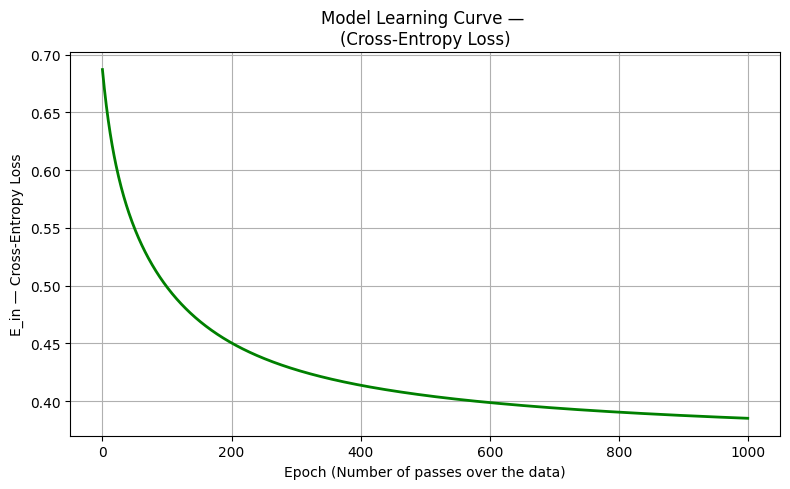

In [ ]:
print("=" * 55)
print("  CS412 Lab 3 — Logistic Regression")
print("=" * 55)
print(f"\nDataset size : {len(y)} samples")
print(f"Training set : {len(y_train)} samples ({len(y_train)/len(y)*100:.0f}%)")
print(f"Test set     : {len(y_test)} samples ({len(y_test)/len(y)*100:.0f}%)")
print(f"Features     : BP, Cholesterol, Age, Pregnant\n")

print("Training logistic regression ...")
print("-" * 45)

w, losses = logistic_regression_train(
    X_train_b, y_train,
    lr=0.1,
    epochs=1000,
    verbose=True
)

plt.figure(figsize=(8, 5))
plt.plot(losses, color='green', linewidth=2)
plt.title("Model Learning Curve — \n(Cross-Entropy Loss)")
plt.xlabel("Epoch (Number of passes over the data)")
plt.ylabel("E_in — Cross-Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7. Final Weight Vector w*

In [ ]:
feature_names = ["Bias", "BP", "Cholesterol", "Age", "Pregnant"]
print("\n" + "=" * 55)
print("  Final Weight Vector  w*")
print("=" * 55)
for name, wi in zip(feature_names, w):
    print(f"  {name:<12} : {wi:+.6f}")



  Final Weight Vector  w*
  Bias         : -0.851996
  BP           : -1.000488
  Cholesterol  : +0.243900
  Age          : +3.037654
  Pregnant     : +2.390703


## 8. Test & Prediction

In [ ]:
y_train_pred = predict(X_train_b, w)
y_test_pred  = predict(X_test_b,  w)

train_acc = accuracy(y_train, y_train_pred)
test_acc  = accuracy(y_test,  y_test_pred)

print("\n" + "=" * 55)
print("  Prediction Results — Test Set")
print("=" * 55)
print(f"  {'Sample':<8} {'True Label':>12} {'Predicted':>12} {'Correct?':>10}")
print("  " + "-" * 46)
for i, (yt, yp) in enumerate(zip(y_test, y_test_pred)):
    correct = "✓" if yt == yp else "✗"
    print(f"  {i+1:<8} {int(yt):>12} {int(yp):>12} {correct:>10}")

print("\n" + "=" * 55)
print("  Classification Accuracy")
print("=" * 55)
print(f"  Training accuracy : {train_acc:.2f}%")
print(f"  Test accuracy     : {test_acc:.2f}%")



  Prediction Results — Test Set
  Sample     True Label    Predicted   Correct?
  ----------------------------------------------
  1                   1            1          ✓
  2                  -1           -1          ✓
  3                   1            1          ✓
  4                   1           -1          ✗
  5                   1            1          ✓
  6                   1            1          ✓
  7                   1            1          ✓
  8                  -1           -1          ✓
  9                  -1           -1          ✓
  10                 -1            1          ✗
  11                  1            1          ✓
  12                 -1            1          ✗

  Classification Accuracy
  Training accuracy : 83.33%
  Test accuracy     : 75.00%
